# AdaBoost


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\Microsoft_Training\heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [54]:
pip install -U scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: C:\Users\ASUS\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [55]:
df.shape

(1025, 14)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [57]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [58]:
df.target

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64

In [59]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [60]:
df.duplicated().sum()

np.int64(723)

In [61]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

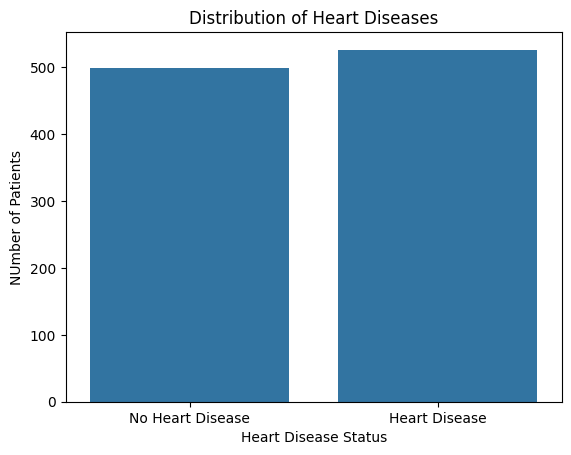

In [62]:
sns.countplot(x="target",data=df)

plt.xticks([0,1],["No Heart Disease","Heart Disease"])
plt.xlabel("Heart Disease Status")
plt.ylabel("NUmber of Patients")
plt.title("Distribution of Heart Diseases")

plt.show()

In [63]:
X = df.drop("target",axis=1)

y = df["target"]

In [64]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


In [65]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [66]:
from sklearn.model_selection import train_test_split 

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [67]:
print("Shape of X_train :", X_train.shape)
print("Shape of X_test  :", X_test.shape)

print("Shape of y_train :", y_train.shape)
print("Shape of y_test  :", y_test.shape)

Shape of X_train : (820, 13)
Shape of X_test  : (205, 13)
Shape of y_train : (820,)
Shape of y_test  : (205,)


In [68]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
 X,
 y,
 test_size=0.2,
 random_state=42,

)

In [69]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [70]:
base_tree = DecisionTreeClassifier(
 max_depth=1,
 random_state=42
)


In [71]:
ada_model = AdaBoostClassifier(
 estimator=base_tree,
 n_estimators=5,
 learning_rate=0.5,
 random_state=42
)

In [72]:
ada_model.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",5
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...ndom_state=42)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](5,)","[0.24,0.26,0.26,0.3 ,0.34]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](5,)","[0.58,0.52,0.51,0.43,0.32]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](13,)","[0. ,0. ,0.25,...,0. ,0.22,0.22]"


In [73]:
y_pred_ada = ada_model.predict(X_test)


In [74]:
print("Number of weak learners:", len(ada_model.estimators_))

Number of weak learners: 5


In [75]:
#Show every individual tree
for i, tree in enumerate(ada_model.estimators_):
 print(f"Tree {i+1}")
 print(tree)

Tree 1
DecisionTreeClassifier(max_depth=1, random_state=1608637542)
Tree 2
DecisionTreeClassifier(max_depth=1, random_state=1273642419)
Tree 3
DecisionTreeClassifier(max_depth=1, random_state=1935803228)
Tree 4
DecisionTreeClassifier(max_depth=1, random_state=787846414)
Tree 5
DecisionTreeClassifier(max_depth=1, random_state=996406378)


In [76]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

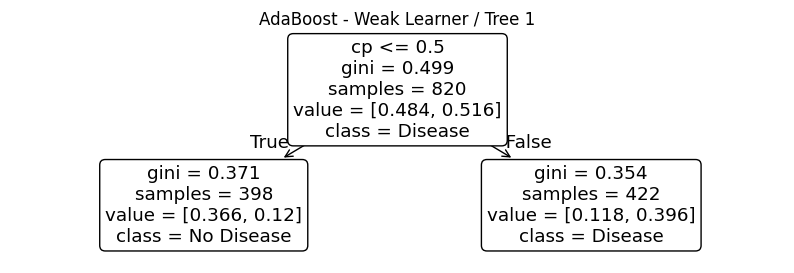

In [77]:
#visualise tree 1
plt.figure(figsize=(10, 3))
plot_tree(
 ada_model.estimators_[0],
 feature_names=X.columns,
 class_names=["No Disease", "Disease"],
 filled=False,
 rounded=True
)
plt.title("AdaBoost - Weak Learner / Tree 1")
plt.show()

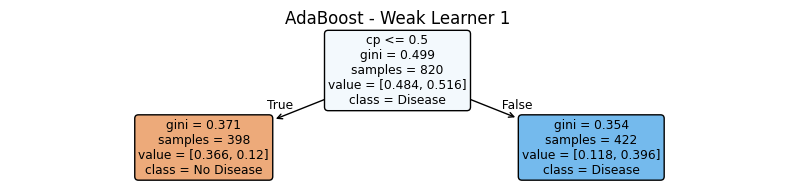

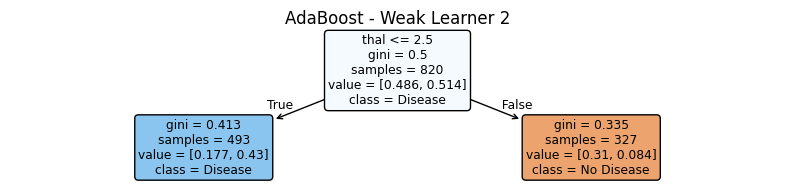

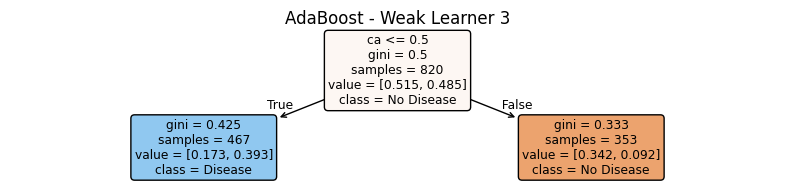

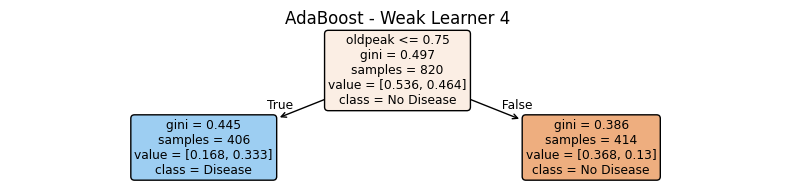

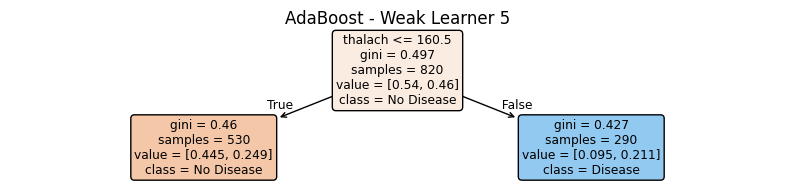

In [78]:
#Visualize all 5 trees
for i, tree in enumerate(ada_model.estimators_):
 plt.figure(figsize=(10, 2))
 plot_tree(
 tree,
 feature_names=X.columns,
 class_names=["No Disease", "Disease"],
 filled=True,
 rounded=True
 )
 plt.title(f"AdaBoost - Weak Learner {i+1}")
 plt.show()


In [79]:
#Tree weights
print("Tree weights:")
for i, weight in enumerate(ada_model.estimator_weights_):
 print(f"Tree {i+1}: {weight:.4f}")


Tree weights:
Tree 1: 0.5824
Tree 2: 0.5226
Tree 3: 0.5105
Tree 4: 0.4276
Tree 5: 0.3244


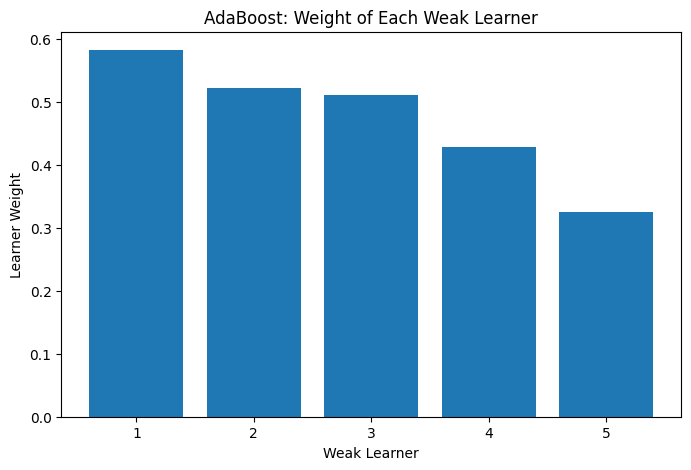

In [80]:
tree_numbers = range(1, len(ada_model.estimator_weights_) + 1)
plt.figure(figsize=(8, 5))
plt.bar(
 tree_numbers,
 ada_model.estimator_weights_
)
plt.xlabel("Weak Learner")
plt.ylabel("Learner Weight")
plt.title("AdaBoost: Weight of Each Weak Learner")
plt.xticks(list(tree_numbers))
plt.show()

In [81]:
#how the samples are weighted
sample_weights = ada_model.estimator_errors_
# estimator_errors_ is not sample weights.
# It contains the error of each weak learner.

In [82]:
print("Weak learner errors:")
for i, error in enumerate(ada_model.estimator_errors_):
 print(f"Tree {i+1}: Error = {error:.4f}")

Weak learner errors:
Tree 1: Error = 0.2378
Tree 2: Error = 0.2602
Tree 3: Error = 0.2648
Tree 4: Error = 0.2983
Tree 5: Error = 0.3432


In [83]:
#AdaBoost's predictions after each tree
from sklearn.metrics import accuracy_score

for i, prediction in enumerate(
 ada_model.staged_predict(X_test)
):
    accuracy = accuracy_score(y_test, prediction)
    print(
         f"After Tree {i+1}: "
         f"Accuracy = {accuracy:.4f}"
 )
   

After Tree 1: Accuracy = 0.7512
After Tree 2: Accuracy = 0.7512
After Tree 3: Accuracy = 0.7854
After Tree 4: Accuracy = 0.7854
After Tree 5: Accuracy = 0.7756


C:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


In [84]:
#Plot accuracy as trees increase
staged_accuracy = []
for prediction in ada_model.staged_predict(X_test):
 accuracy = accuracy_score(y_test, prediction)
 staged_accuracy.append(accuracy)

C:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


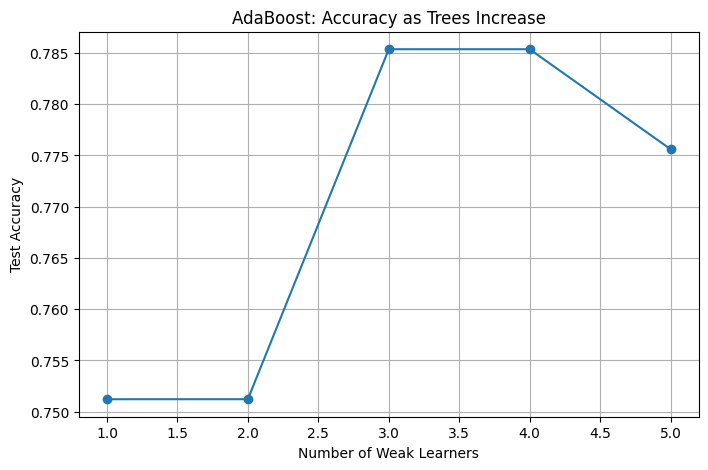

In [85]:
plt.figure(figsize=(8, 5))
plt.plot(
 range(1, len(staged_accuracy) + 1),
 staged_accuracy,
 marker="o"
)
plt.xlabel("Number of Weak Learners")
plt.ylabel("Test Accuracy")
plt.title("AdaBoost: Accuracy as Trees Increase")
plt.grid(True)
plt.show()

In [86]:
y_pred_ada = ada_model.predict(X_test)

In [87]:
from sklearn.metrics import classification_report
print(classification_report(
 y_test,
 y_pred_ada,
 target_names=["No Disease", "Disease"]
))

              precision    recall  f1-score   support

  No Disease       0.78      0.76      0.77       102
     Disease       0.77      0.79      0.78       103

    accuracy                           0.78       205
   macro avg       0.78      0.78      0.78       205
weighted avg       0.78      0.78      0.78       205



# XGBOOST

In [88]:
# Install XGBoost
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [89]:
from xgboost import XGBClassifier
print("Libraries Imported Successfully")


Libraries Imported Successfully


In [90]:
model = XGBClassifier(
 n_estimators=50,
 max_depth=None,
 learning_rate=0.1,
 random_state=42
)
model

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [91]:
model = XGBClassifier(
 n_estimators=50,
 max_depth=5,
 learning_rate=0.1,
 subsample=0.8,
 colsample_bytree=0.8,
 gamma=1,
 random_state=42
)

In [93]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
 X,
 y,
 test_size=0.2,
 random_state=42,

)

In [95]:
model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [96]:
y_pred = model.predict(X_test)

In [97]:
comparison = pd.DataFrame({
 "Actual": y_test,
 "Predicted": y_pred
})
comparison.head(10)

,Actual,Predicted
527,1,1
359,1,1
447,0,0
31,1,1
621,0,0
590,1,1
905,0,0
737,0,0
76,1,1
948,0,0


In [98]:
# Accuracy
# ============================================
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 0.9609756097560975


In [99]:
# Confusion Matrix
# ============================================
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[100   2]
 [  6  97]]


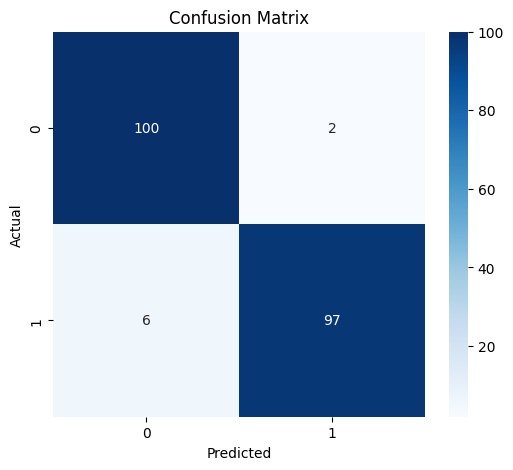

In [100]:
plt.figure(figsize=(6,5)) 
sns.heatmap(
 cm,
 annot=True,
 cmap="Blues",
 fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [101]:
# Classification Report
# ============================================
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred)) 

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       102
           1       0.98      0.94      0.96       103

    accuracy                           0.96       205
   macro avg       0.96      0.96      0.96       205
weighted avg       0.96      0.96      0.96       205



In [102]:
# ============================================
# Predict a New Patient
# ============================================
new_patient = [[55,1,2,130,250,0,1,150,0,1.2,2,0,2]]

prediction = model.predict(new_patient)
print("Predicted Class :", prediction[0])
if prediction[0] == 1:
 print("The patient is likely to have Heart Disease.")
else:
 print("The patient is unlikely to have Heart Disease.")


Predicted Class : 1
The patient is likely to have Heart Disease.


In [103]:
# Feature Importance
# ============================================
importance = pd.DataFrame({
 "Feature": X.columns,
 "Importance": model.feature_importances_
})
importance = importance.sort_values(
 by="Importance",
 ascending=False
)
importance

,Feature,Importance
12,thal,0.199252
2,cp,0.176129
11,ca,0.134270
9,oldpeak,0.088457
10,slope,0.069201
1,sex,0.057047
8,exang,0.049802
0,age,0.044802
7,thalach,0.043544
3,trestbps,0.041490


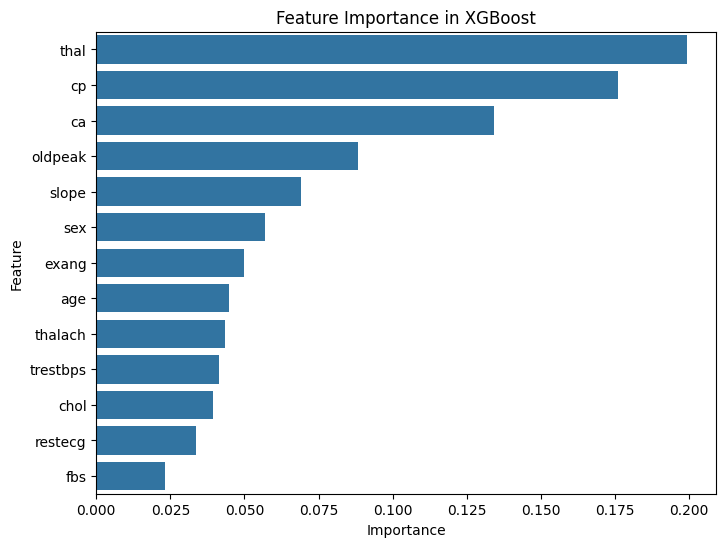

In [104]:
# Plot Feature Importance
# ============================================
plt.figure(figsize=(8,6))
sns.barplot(
 x="Importance",
 y="Feature",
 data=importance
)
plt.title("Feature Importance in XGBoost")
plt.show()

<Figure size 1000x800 with 0 Axes>

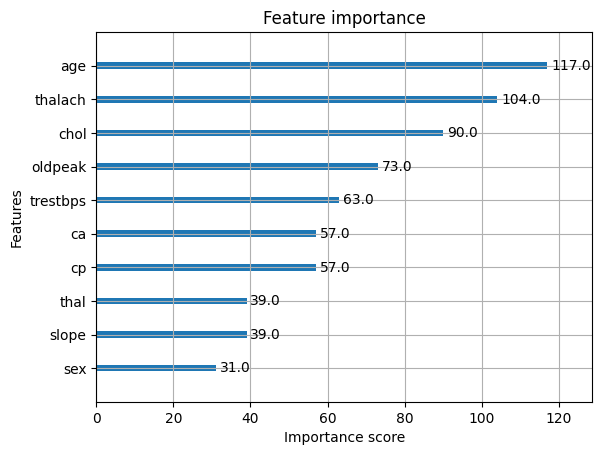

In [105]:
# XGBoost Feature Importance Plot
# ============================================
from xgboost import plot_importance
plt.figure(figsize=(10,8))
plot_importance(
 model,
 max_num_features=10
)
plt.show()

In [106]:
# Calculate Evaluation Metrics
# ============================================
from sklearn.metrics import (
 accuracy_score,
 precision_score,
 recall_score,
 f1_score
)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall : {recall*100:.2f}%")
print(f"F1 Score : {f1*100:.2f}%")

Accuracy : 96.10%
Precision: 97.98%
Recall : 94.17%
F1 Score : 96.04%
